## image-to-text using an LLM

This notebook tests the multimodal (image-to-text) capabilities of the Mistral-Small-3.1-24B-Instruct model deployed on OpenShift AI with vLLM.

It allows you to send both text and image data to the model and receive a natural-language description or caption of the image. 

🧩 What the code does (step by step)

	1.	Load an image
    
	2.	Convert the image to base64
    
	3.	Build and send a chat-style multimodal request

In [1]:
#!pip install pillow matplotlib requests

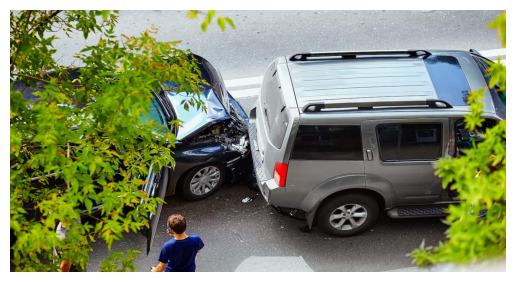

🧠 Model response:

In this image, two SUVs have been involved in a collision on a rain-soaked road. The front ends of both vehicles are visibly damaged, with the hoods crumpled and the hood of the black SUV raised visibly, suggesting significant front-end damage.

Details of the vehicles:
1. On the left, there is a black SUV with tinted windows. It has a noticeable dent on its front bumper, and the hood is cracked and raised upward.
2. On the right, there is a silver SUV, also with noticeably damaged front end. The hood of this vehicle is open, displaying the engine underneath, and part of the front bumper appears damaged.

In the foreground on the right side, a person wearing a dark blue T-shirt is standing and looking at the accident. They seem to be assessing the damage.

The background includes lush, green trees and overhanging branches, giving the impression that the accident occurred in a semi-urban or suburban area. The road surface appears wet, indicating recent or ongoing rain

In [ ]:
import base64
from PIL import Image
import matplotlib.pyplot as plt
import requests

# Encode local image as base64
with open("assets/images/car-accident.jpg", "rb") as f:
    image_b64 = base64.b64encode(f.read()).decode("utf-8")

# Embed base64 as data URI
data_uri = f"data:image/jpeg;base64,{image_b64}"

# Display image
img = Image.open("assets/images/car-accident.jpg")
plt.imshow(img)
plt.axis("off")
plt.show()

# Endpoint & headers
endpoint_url = "https://redhataimistral-small-quantizedw4a16-mistral.apps.cluster-d44sv.d44sv.sandbox2961.opentlc.com/v1/chat/completions"
headers = {"Content-Type": "application/json", "Authorization": "Bearer xxx"}   # replace xxx with your own token!!!


# ✅ Correct multimodal payload for Mistral-vLLM
data = {
    "model": "redhataimistral-small-quantizedw4a16",
    "messages": [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": "Describe this image in detail."},
                {"type": "image_url", "image_url": {"url": data_uri}}
            ]
        }
    ],
    "max_tokens": 256
}

response = requests.post(endpoint_url, headers=headers, json=data)

print("🧠 Model response:\n")
print(response.json()["choices"][0]["message"]["content"])